In [1]:

import torch
import numpy as np
import time
import matplotlib.pyplot as plt

# Define the range of inputs (x) and dimensions (D) to test
# Using powers of 10 to see the scaling effect clearly
num_inputs_range = [10, 100, 1000, 10000, 100000]
dimensions_range = [10, 100, 1000, 5000, 10000]

# Initialize a 2D numpy array to store the timing results
# Rows will correspond to the number of inputs, columns to dimensions
timing_results = np.zeros((len(num_inputs_range), len(dimensions_range)))

print("Starting benchmark...")

# Iterate over each combination of num_inputs and dimensions
for i, x in enumerate(num_inputs_range):
    for j, D in enumerate(dimensions_range):
        # Record the start time
        start_time = time.time()
        
        # Generate the random tensor. We don't need to store it.
        _ = torch.rand((x, D))
        
        # Record the end time
        end_time = time.time()
        
        # Calculate the duration and store it in our results array
        duration = end_time - start_time
        timing_results[i, j] = duration
        
        print(f"Generated ({x:7d}, {D:5d}) tensor in {duration:.6f} seconds.")

print("\nBenchmark finished.")


Starting benchmark...
Generated (     10,    10) tensor in 0.000664 seconds.
Generated (     10,   100) tensor in 0.000036 seconds.
Generated (     10,  1000) tensor in 0.000056 seconds.
Generated (     10,  5000) tensor in 0.000260 seconds.
Generated (     10, 10000) tensor in 0.000496 seconds.
Generated (    100,    10) tensor in 0.000008 seconds.
Generated (    100,   100) tensor in 0.000043 seconds.
Generated (    100,  1000) tensor in 0.000410 seconds.
Generated (    100,  5000) tensor in 0.002525 seconds.
Generated (    100, 10000) tensor in 0.005010 seconds.
Generated (   1000,    10) tensor in 0.000164 seconds.
Generated (   1000,   100) tensor in 0.000402 seconds.
Generated (   1000,  1000) tensor in 0.004882 seconds.
Generated (   1000,  5000) tensor in 0.024948 seconds.
Generated (   1000, 10000) tensor in 0.050323 seconds.
Generated (  10000,    10) tensor in 0.001654 seconds.
Generated (  10000,   100) tensor in 0.004179 seconds.
Generated (  10000,  1000) tensor in 0.0493

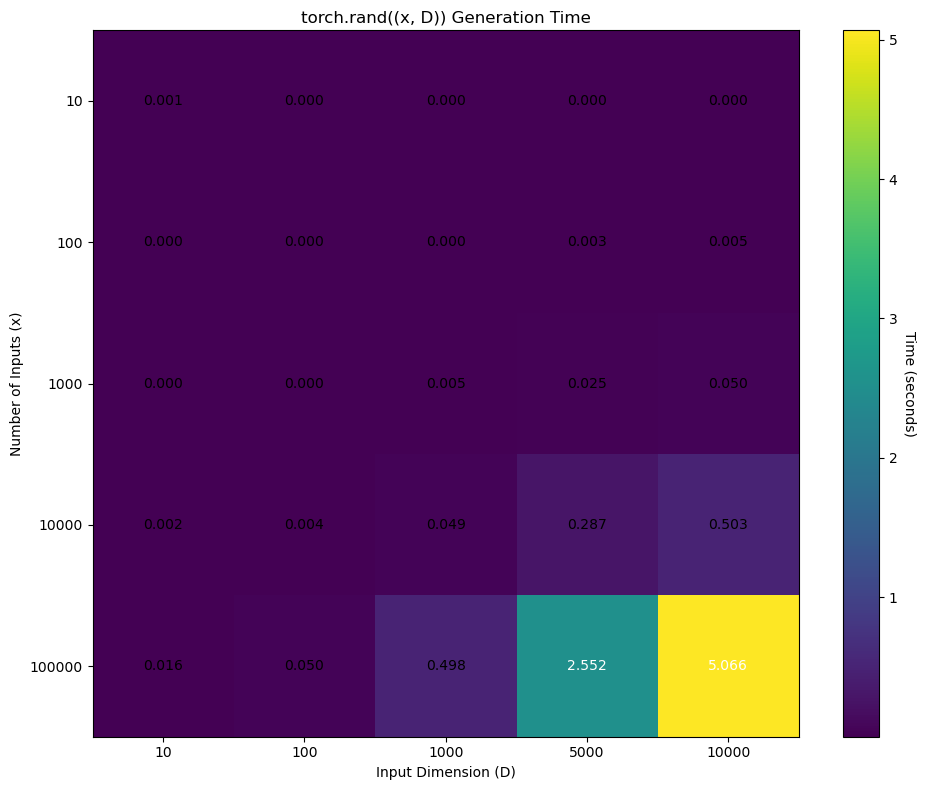

In [2]:
# --- Plotting the results ---
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(timing_results, cmap='viridis')

# Create a colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Time (seconds)", rotation=-90, va="bottom")

# Set the ticks and labels for x and y axes
ax.set_xticks(np.arange(len(dimensions_range)), labels=dimensions_range)
ax.set_yticks(np.arange(len(num_inputs_range)), labels=num_inputs_range)

# Set axis labels and title
ax.set_xlabel("Input Dimension (D)")
ax.set_ylabel("Number of Inputs (x)")
ax.set_title("torch.rand((x, D)) Generation Time")

# Loop over data dimensions and create text annotations
for i in range(len(num_inputs_range)):
    for j in range(len(dimensions_range)):
        # Use a contrasting color for the text based on the background brightness
        color = "black" if timing_results[i, j] < timing_results.max() / 2 else "white"
        text = ax.text(j, i, f"{timing_results[i, j]:.3f}",
                       ha="center", va="center", color=color)

fig.tight_layout()
plt.show()